In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\shreyaash mogaveera\sentiment-analysis-nlp\data\IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df['review'][4]

'Petter Mattei\'s "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler\'s play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is connected in one way, or another to the next person, but no one seems to know the previous point of contact. Stylishly, the film has a sophisticated luxurious look. We are taken to see how these people live and the world they live in their own habitat.<br /><br />The only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits. A big city is not exactly the best place in which human relations find sincere fulfillment, as one discerns is the case wit

In [5]:
df.shape

(50000, 2)

In [6]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
df['review_length']=df['review'].apply(len)
df['review_length'].mean()

np.float64(1309.43102)

In [13]:
df['word_count']=df['review'].apply(lambda x: len(x.split()))
df['word_count'].mean()

np.float64(231.15694)

In [8]:
df.isnull().sum()

review           0
sentiment        0
review_length    0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review         50000 non-null  object
 1   sentiment      50000 non-null  object
 2   review_length  50000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

np.int64(418)

## Key insights
 - dataset contains 50000 rows n 2 columns
 - HTML tags are present in reviews
 - data is perfectly balanced between positive and negative
 - average: ~1300 characters, ~230 words
 - there are no missing values but it contains 418 duplicate data

In [21]:
!pip install wordcloud

In [22]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

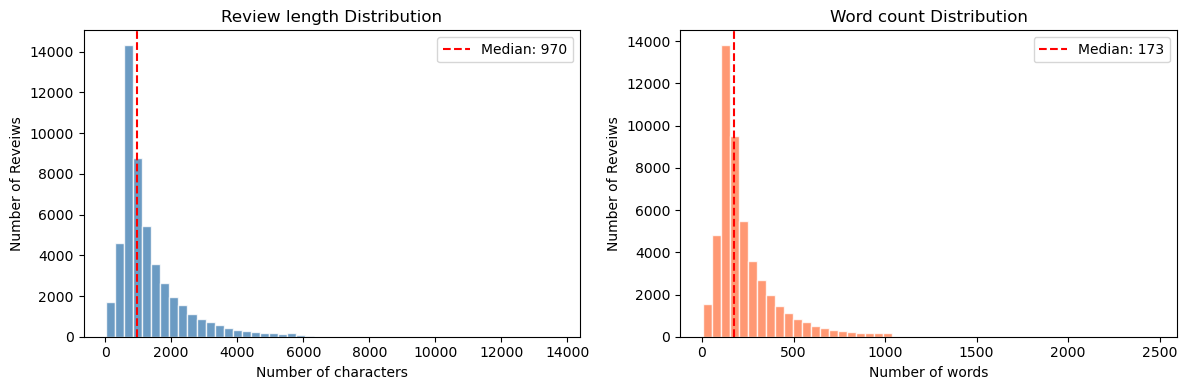

In [27]:
#plot distributions
fig,axes=plt.subplots(1,2,figsize=(12,4))
#left graph: character count 
axes[0].hist(df['review_length'],bins=50,color='steelblue',edgecolor='white',alpha=0.8)
axes[0].set_title('Review length Distribution')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Number of Reveiws')
axes[0].axvline(df['review_length'].median(),color='red',linestyle='--',label=f"Median: {df['review_length'].median():.0f}")
axes[0].legend()

#right graph: word count
axes[1].hist(df['word_count'],bins=50,color='coral',edgecolor='white',alpha=0.8)
axes[1].set_title('Word count Distribution')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Number of Reveiws')
axes[1].axvline(df['word_count'].median(),color='red',linestyle='--',label=f"Median: {df['word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/length_distribution.png')

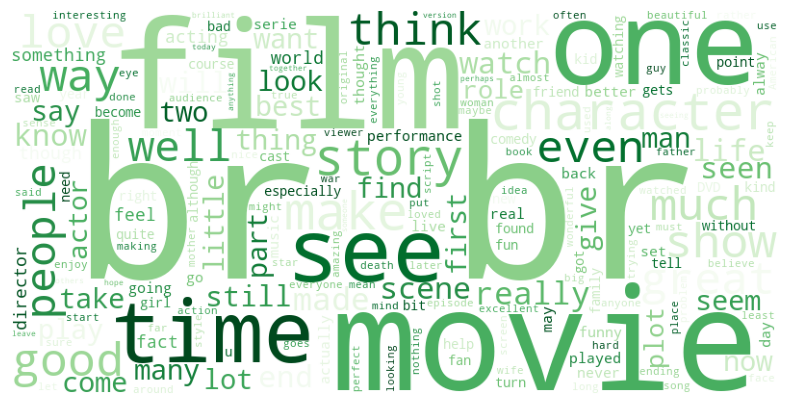

In [31]:
#word cloud for positive reveiws
positive_text=' '.join(df[df['sentiment']=='positive']['review'])
wordcloud_pos=WordCloud(width=800,height=400,background_color='white',colormap='Greens').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.savefig('../assets/wordcloud_positive.png')

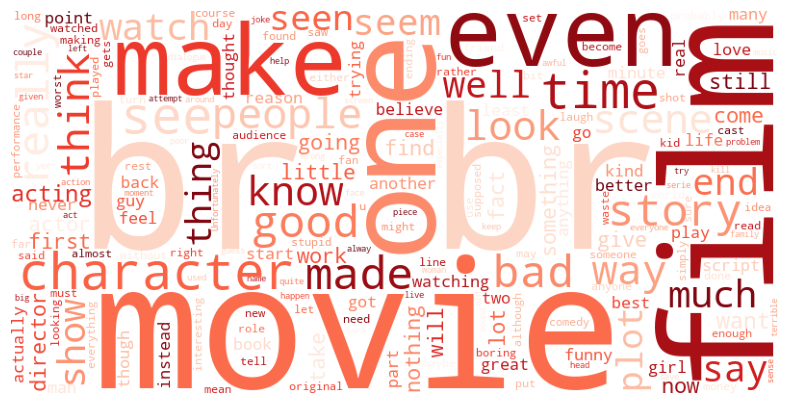

In [33]:
#word cloud for negative reviews
negative_text=' '.join(df[df['sentiment']=='negative']['review'])
wordcloud_pos=WordCloud(width=800,height=400,background_color='white',colormap='Reds').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.savefig('../assets/wordcloud_negative.png')

In [3]:
#creating sample reviews
sample = df.groupby('sentiment').apply(lambda x: x.sample(250, random_state=42)).reset_index(drop=True)

# Shuffle the rows
sample = sample.sample(frac=1, random_state=42).reset_index(drop=True)

sample.to_csv(r"C:\Users\shreyaash mogaveera\sentiment-analysis-nlp\data\sample_reviews.csv",index=False)

# Verify
print(f"Sample shape: {sample.shape}")
print(f"Sentiment distribution:")
print(sample['sentiment'].value_counts())
print("\nFirst few rows:")
print(sample.head())

Sample shape: (500, 2)
Sentiment distribution:
sentiment
positive    250
negative    250
Name: count, dtype: int64

First few rows:
                                              review sentiment
0  amazing movie I saw this movie for the first t...  positive
1  Well I just paid a dollar for a DVD of this mo...  negative
2  It is Queen Victoria's misfortune to be define...  positive
3  It seems the makers of this film had trouble d...  negative
4  The final film for Ernst Lubitsch, completed b...  negative


C:\Users\shreyaash mogaveera\AppData\Local\Temp\ipykernel_12020\3990734124.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('sentiment').apply(lambda x: x.sample(250, random_state=42)).reset_index(drop=True)
